# Week 5 workshop · Vicsek flocking


**Canonical model:** Vicsek flocking.

**Modelling practice:** Stochastic implementation choices can change conclusions.

**Why it matters:** Two plausible ways of adding noise can produce different collective transitions, so the stochastic rule is part of the model rather than incidental code.

Angular and vectorial noise are implemented and compared using matched sweeps and ensembles.

By the end, you should be able to compare two defensible implementations of noise using matched parameter sweeps and stochastic ensembles.

# From the lecture to the workshop

The lecture moved from fixed Ising spins, through continuous XY orientations, to moving Vicsek agents. This workshop stays deliberately close to the Vicsek model so every plotted result can be traced back to a tested update rule. If positions are held fixed, the agents form a static alignment network with XY-like orientation dynamics. Allowing them to move makes the interaction network change through time. This is a conceptual bridge to the XY model, not an implementation of its equilibrium dynamics.

This notebook needs Python 3.10 or later, NumPy, Matplotlib, and IPython. It is self-contained and does not require the lecture repository or separate data files. Run the cells in order from a fresh kernel.

In [15]:
from dataclasses import dataclass
import json

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, **kwargs):
        return iterable

SEED = 3024
INK = "#1B2A4C"
BLUE = "#5879AA"
YELLOW = "#EDCC55"

print(f"NumPy {np.__version__} · seed {SEED}")


NumPy 2.4.2 · seed 3024


# Specify the model

| Ingredient | Workshop choice |
|---|---|
| World | square of side length $L$ with periodic boundaries |
| Agent state | position $(x_i,y_i)$ and heading $\theta_i$ |
| Motion | constant speed $v$ |
| Interaction | all agents within metric radius $R$, including self |
| Heading update | direction of mean neighbour velocity plus a stated noise convention |
| Position update | move using the old heading, as in the original model |
| Clock | synchronous discrete steps |
| Observable | polarisation $\Phi$ |

> **Modelling choice:** The interaction rule, noise convention, update order, and boundary conditions all define the model.


In [16]:
@dataclass(frozen=True)
class VicsekParameters:
    n_agents: int = 80
    box_size: float = 10.0
    speed: float = 0.10
    radius: float = 1.0
    noise: float = 0.8
    noise_mode: str = "angular"
    dt: float = 1.0

    def __post_init__(self):
        if self.n_agents < 1:
            raise ValueError("n_agents must be positive")
        if min(self.box_size, self.radius, self.dt) <= 0 or self.speed < 0:
            raise ValueError("box_size, radius, and dt must be positive; speed cannot be negative")
        if self.noise < 0:
            raise ValueError("noise must be non-negative")
        if self.noise_mode not in {"angular", "vectorial"}:
            raise ValueError("noise_mode must be 'angular' or 'vectorial'")


def initialise_vicsek(params: VicsekParameters, rng: np.random.Generator):
    positions = rng.uniform(0, params.box_size, size=(params.n_agents, 2))
    headings = rng.uniform(-np.pi, np.pi, size=params.n_agents)
    return positions, headings


# Test the periodic geometry

For a periodic square, agents close to opposite edges may be neighbours. The minimum-image displacement wraps each coordinate into $[-L/2,L/2)$.

> **Discuss:** Two agents have $x$ coordinates $0.2$ and $9.8$ in a box with $L=10$. What is their periodic separation in the $x$ direction?


In [17]:
def periodic_displacements(positions: np.ndarray, box_size: float) -> np.ndarray:
    """Return pairwise minimum-image displacement vectors x_j - x_i."""
    positions = np.asarray(positions, dtype=float)
    if positions.ndim != 2 or positions.shape[1] != 2:
        raise ValueError("positions must have shape (n_agents, 2)")
    displacement = positions[None, :, :] - positions[:, None, :]
    return (displacement + box_size / 2) % box_size - box_size / 2


edge_case = np.array([[0.2, 5.0], [9.8, 5.0]])
edge_displacement = periodic_displacements(edge_case, 10.0)
assert np.isclose(abs(edge_displacement[0, 1, 0]), 0.4)
assert np.allclose(edge_displacement[0, 1], -edge_displacement[1, 0])
print("Periodic-distance tests passed.")


Periodic-distance tests passed.


# Apply one synchronous update

For each agent:

1. find neighbours from the old positions;
2. average their unit velocity vectors;
3. add independent angular noise to obtain the next heading;
4. move using the old heading;
5. wrap the new position into the periodic box.

All agents must be updated from the same previous state.


In [18]:
def vicsek_step(
    positions: np.ndarray,
    headings: np.ndarray,
    params: VicsekParameters,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    """Apply one synchronous Vicsek update."""
    positions = np.asarray(positions, dtype=float)
    headings = np.asarray(headings, dtype=float)
    if positions.shape != (params.n_agents, 2) or headings.shape != (params.n_agents,):
        raise ValueError("state shapes do not match params.n_agents")

    displacement = periodic_displacements(positions, params.box_size)
    distances_squared = np.sum(displacement**2, axis=2)
    neighbours = distances_squared <= params.radius**2

    sum_x = neighbours @ np.cos(headings)
    sum_y = neighbours @ np.sin(headings)
    mean_heading = np.arctan2(sum_y, sum_x)

    if params.noise_mode == "angular":
        # Rotate the locally aligned direction by a random angle.
        angular_noise = rng.uniform(-params.noise / 2, params.noise / 2, params.n_agents)
        new_headings = mean_heading + angular_noise
    else:
        # Perturb the mean neighbour vector before extracting its direction.
        neighbour_count = neighbours.sum(axis=1)
        mean_x = sum_x / neighbour_count
        mean_y = sum_y / neighbour_count
        random_direction = rng.uniform(-np.pi, np.pi, params.n_agents)
        noisy_x = mean_x + params.noise * np.cos(random_direction)
        noisy_y = mean_y + params.noise * np.sin(random_direction)
        new_headings = np.arctan2(noisy_y, noisy_x)

    new_headings = (new_headings + np.pi) % (2 * np.pi) - np.pi

    velocity = params.speed * np.column_stack((np.cos(headings), np.sin(headings)))
    new_positions = (positions + params.dt * velocity) % params.box_size
    return new_positions, new_headings


## Check limiting cases

With zero speed, positions should not change. With identical headings and zero noise, headings should remain identical.


In [19]:
test_positions = np.array([[0., 0.], [1., 0.], [0., 1.], [1., 1.]])
test_headings = np.full(4, 0.7)
for noise_mode in ("angular", "vectorial"):
    test_params = VicsekParameters(
        n_agents=4, box_size=4, speed=0, radius=5, noise=0, noise_mode=noise_mode
    )
    new_positions, new_headings = vicsek_step(
        test_positions, test_headings, test_params, np.random.default_rng(SEED)
    )
    assert np.allclose(new_positions, test_positions)
    assert np.allclose(new_headings, test_headings)
    assert not np.shares_memory(new_positions, test_positions)
print("One-step tests passed.")


One-step tests passed.


# Simulate and record

The history includes the initial state at time zero. Keeping positions and headings separate makes it possible to inspect trajectories and calculate observables without rerunning the model.


In [20]:
def simulate_vicsek(params: VicsekParameters, steps: int, seed: int):
    if not isinstance(steps, (int, np.integer)) or steps < 0:
        raise ValueError("steps must be a non-negative integer")
    rng = np.random.default_rng(seed)
    positions, headings = initialise_vicsek(params, rng)
    position_history = np.empty((steps + 1, params.n_agents, 2))
    heading_history = np.empty((steps + 1, params.n_agents))
    position_history[0], heading_history[0] = positions, headings
    for time in range(1, steps + 1):
        positions, headings = vicsek_step(positions, headings, params, rng)
        position_history[time], heading_history[time] = positions, headings
    return position_history, heading_history


baseline = VicsekParameters()
positions_history, headings_history = simulate_vicsek(baseline, steps=200, seed=SEED)
print("history shapes:", positions_history.shape, headings_history.shape)


history shapes: (201, 80, 2) (201, 80)


## Improve the representation progressively

The same agent state can be drawn in several ways. Compare the four encodings before deciding which one communicates the model most clearly.

- **Dots** show where agents are, but discard their headings.
- **Bars** add orientation, but not which end points forward.
- **Arrows** show position, orientation, and direction of travel.
- **Coloured arrows** also encode heading as a cyclic colour. This can make aligned groups easier to find, but colour should reinforce rather than replace the arrow direction.

> **Modelling choice:** A figure is another model of the data. Include only encodings that help answer the question, and check that the conclusion remains visible without colour.


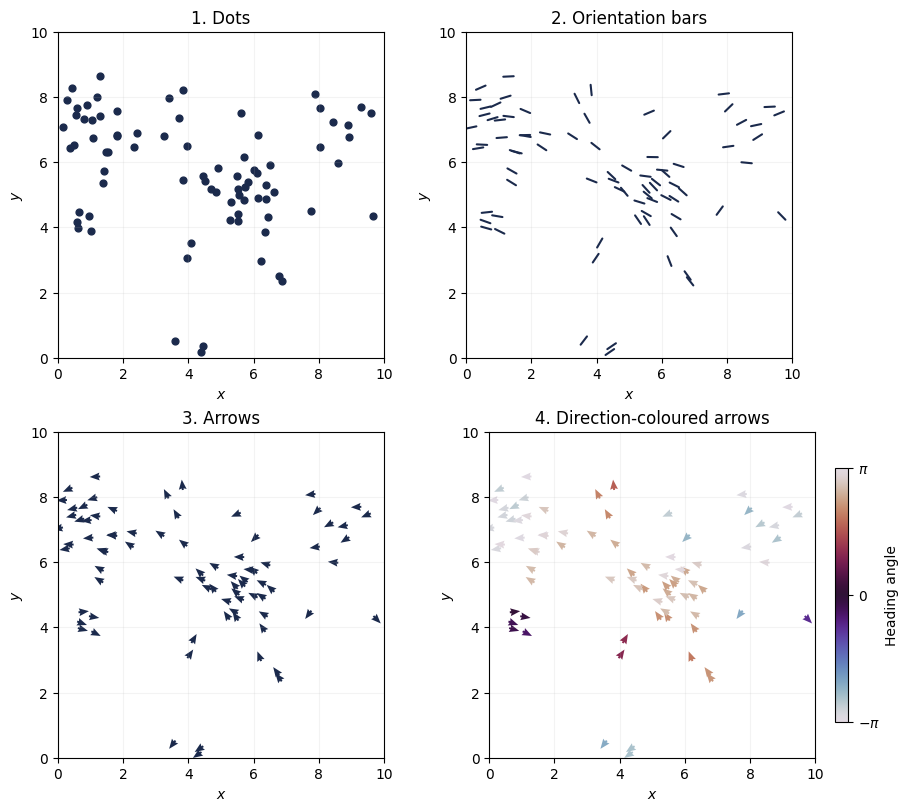

In [21]:
def compare_agent_encodings(positions, headings, box_size):
    """Show progressively richer views of one Vicsek-model state."""
    positions = np.asarray(positions)
    headings = np.asarray(headings)
    dx, dy = np.cos(headings), np.sin(headings)

    fig, axes = plt.subplots(2, 2, figsize=(9, 8), constrained_layout=True)
    titles = ["1. Dots", "2. Orientation bars", "3. Arrows", "4. Direction-coloured arrows"]

    axes[0, 0].scatter(positions[:, 0], positions[:, 1], s=24, color=INK)

    bar_half_length = 0.16
    for (x, y), ux, uy in zip(positions, dx, dy):
        axes[0, 1].plot(
            [x - bar_half_length * ux, x + bar_half_length * ux],
            [y - bar_half_length * uy, y + bar_half_length * uy],
            color=INK, lw=1.5, solid_capstyle="round"
        )

    arrow_scale = 0.32
    axes[1, 0].quiver(
        positions[:, 0], positions[:, 1], dx, dy,
        color=INK, angles="xy", scale_units="xy", scale=1 / arrow_scale,
        width=0.006, headwidth=4, headlength=5
    )

    coloured = axes[1, 1].quiver(
        positions[:, 0], positions[:, 1], dx, dy, headings,
        cmap="twilight", norm=plt.Normalize(-np.pi, np.pi),
        angles="xy", scale_units="xy", scale=1 / arrow_scale,
        width=0.006, headwidth=4, headlength=5
    )
    colourbar = fig.colorbar(coloured, ax=axes[1, 1], shrink=0.78, pad=0.03)
    colourbar.set_label("Heading angle")
    colourbar.set_ticks([-np.pi, 0, np.pi], labels=[r"$-\pi$", "0", r"$\pi$"])

    for ax, title in zip(axes.flat, titles):
        ax.set(
            title=title, xlim=(0, box_size), ylim=(0, box_size),
            xlabel="$x$", ylabel="$y$", aspect="equal"
        )
        ax.grid(alpha=0.15)
    return fig, axes


snapshot = 40
compare_agent_encodings(
    positions_history[snapshot], headings_history[snapshot], baseline.box_size
)
plt.show()


## Pause the process

Use the time slider to inspect how local headings become coordinated. The representation menu changes only the display, not the stored model state. Direction-coloured arrows are the default because arrow orientation remains readable without colour while cyclic colour makes similarly aligned groups easier to find.

> **Down the ladder:** inspect individual positions, headings, and neighbours before summarising the flock. Use this view to explain the mechanism and to debug it: pause on one update and check that neighbours, headings, motion, and boundary wrapping agree with the rule you intended to code.


In [22]:
def vicsek_player(
    position_history,
    heading_history,
    box_size,
    element_id="vicsek-player",
    representation="coloured_arrows",
):
    """Interactive Vicsek display with a changeable visual representation."""
    allowed = {"dots", "bars", "arrows", "coloured_arrows"}
    if representation not in allowed:
        raise ValueError(f"representation must be one of {sorted(allowed)}")

    positions_json = json.dumps(np.round(position_history, 4).tolist())
    headings_json = json.dumps(np.round(heading_history, 4).tolist())
    return HTML(f"""
    <div id="{element_id}" style="font-family:Arial,sans-serif;color:#1B2A4C;max-width:900px">
      <canvas width="650" height="650" style="width:min(100%,520px);border:1px solid #C7CEDC"></canvas>
      <div style="display:flex;gap:10px;align-items:center;max-width:650px;flex-wrap:wrap">
        <button type="button">Play</button>
        <input type="range" min="0" max="{len(position_history)-1}" value="0" style="flex:1;min-width:220px;accent-color:#1B2A4C">
        <span></span>
        <label>Representation
          <select>
            <option value="dots">Dots</option>
            <option value="bars">Bars</option>
            <option value="arrows">Arrows</option>
            <option value="coloured_arrows">Direction-coloured arrows</option>
          </select>
        </label>
      </div>
    </div>
    <script>
    (() => {{
      const root=document.getElementById('{element_id}');
      const pos={positions_json}, ang={headings_json}, L={box_size};
      const canvas=root.querySelector('canvas'), ctx=canvas.getContext('2d');
      const slider=root.querySelector('input'), button=root.querySelector('button');
      const label=root.querySelector('span'), select=root.querySelector('select');
      select.value='{representation}';
      let timer=null;

      function arrow(x,y,a,colour,head=true) {{
        const length=13, x2=x+length*Math.cos(a), y2=y-length*Math.sin(a);
        ctx.strokeStyle=colour; ctx.fillStyle=colour; ctx.lineWidth=2;
        ctx.beginPath(); ctx.moveTo(x,y); ctx.lineTo(x2,y2); ctx.stroke();
        if(head) {{
          const h=4.5;
          ctx.beginPath();
          ctx.moveTo(x2,y2);
          ctx.lineTo(x2-h*Math.cos(a-0.55),y2+h*Math.sin(a-0.55));
          ctx.lineTo(x2-h*Math.cos(a+0.55),y2+h*Math.sin(a+0.55));
          ctx.closePath(); ctx.fill();
        }}
      }}

      function draw(k) {{
        ctx.clearRect(0,0,canvas.width,canvas.height);
        ctx.fillStyle='#fff'; ctx.fillRect(0,0,canvas.width,canvas.height);
        const scale=canvas.width/L, mode=select.value;
        pos[k].forEach((p,i)=>{{
          const x=p[0]*scale, y=(L-p[1])*scale, a=ang[k][i];
          if(mode==='dots') {{
            ctx.fillStyle='#1B2A4C'; ctx.beginPath(); ctx.arc(x,y,3.2,0,2*Math.PI); ctx.fill();
          }} else if(mode==='bars') {{
            arrow(x,y,a,'#1B2A4C',false);
          }} else if(mode==='arrows') {{
            arrow(x,y,a,'#1B2A4C',true);
          }} else {{
            const hue=((a%(2*Math.PI)+2*Math.PI)%(2*Math.PI))*180/Math.PI;
            arrow(x,y,a,`hsl(${{hue}},72%,42%)`,true);
          }}
        }});
        label.textContent=`t = ${{k}}`;
      }}
      function stop() {{clearInterval(timer);timer=null;button.textContent='Play';}}
      button.onclick=()=>{{if(timer){{stop();return;}}button.textContent='Pause';timer=setInterval(()=>{{let k=+slider.value;if(k>=pos.length-1){{stop();return;}}slider.value=k+1;draw(k+1);}},100);}};
      slider.oninput=()=>draw(+slider.value);
      select.onchange=()=>draw(+slider.value);
      draw(0);
    }})();
    </script>
    """)


display(vicsek_player(
    positions_history,
    headings_history,
    baseline.box_size,
    representation="coloured_arrows",
))


# Measure collective alignment

$$
\Phi(t)=\frac{1}{N}\left|\sum_{i=1}^{N}e^{\mathrm{i}\theta_i(t)}\right|.
$$

> **Discuss:** What configurations give $\Phi=1$? Can a structured configuration give $\Phi\approx0$?


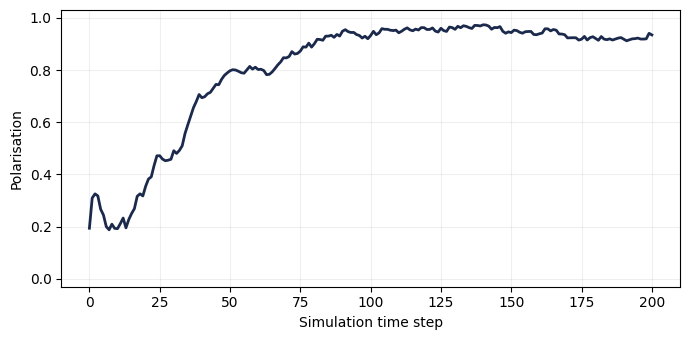

In [23]:
def polarisation(headings: np.ndarray) -> np.ndarray:
    """Return polarisation for one heading vector or a time-by-agent array."""
    headings = np.asarray(headings, dtype=float)
    if headings.ndim not in (1, 2):
        raise ValueError("headings must be one- or two-dimensional")
    return np.abs(np.mean(np.exp(1j * headings), axis=-1))


assert np.isclose(polarisation(np.zeros(5)), 1.0)
assert np.isclose(polarisation(np.array([0, np.pi / 2, np.pi, -np.pi / 2])), 0.0)

phi_history = polarisation(headings_history)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(phi_history, color=INK, lw=2)
ax.set(xlabel="Simulation time step", ylabel="Polarisation", ylim=(-0.03, 1.03))
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()


# Apply the computational budget

Week 4 treated computation as a finite budget. The same constraint now matters more: this straightforward Vicsek implementation checks all pairs of $N$ agents, so one time step costs approximately $O(N^2)$.

A study with $T$ steps, $P$ noise values, and $S$ seeds therefore has approximate cost

$$O(PSTN^2).$$

Use that estimate to choose feasible values before running the sweep. A progress bar reports progress; it does not replace a justified choice of population, runtime, parameter grid, or ensemble size.

> **This week's decision remains about noise:** spend enough of the budget on repeated runs to distinguish a change caused by the noise model from variation between stochastic realisations.


In [24]:
def planned_updates(n_parameter_values, n_seeds, n_steps, n_agents):
    runs = n_parameter_values * n_seeds
    agent_updates = runs * n_steps * n_agents
    pair_checks = runs * n_steps * n_agents**2
    return runs, agent_updates, pair_checks


runs, agent_updates, pair_checks = planned_updates(
    n_parameter_values=7, n_seeds=8, n_steps=180, n_agents=80
)
print(f"Planned runs: {runs:,}")
print(f"Agent updates: {agent_updates:,}")
print(f"Approximate pair checks: {pair_checks:,}")


Planned runs: 56
Agent updates: 806,400
Approximate pair checks: 64,512,000


# First sweep the noise

Use the same initial seed at each noise value. This paired comparison uses the same initial state and underlying random-number sequence, reducing one source of variation while showing how this particular history responds to the parameter.

Only the angular-noise width $\eta$ changes. Population size, density, speed, interaction radius, system size, runtime, and averaging window remain fixed.

> **Up the ladder over noise:** compare simulations to reveal a system-level change in collective behaviour.


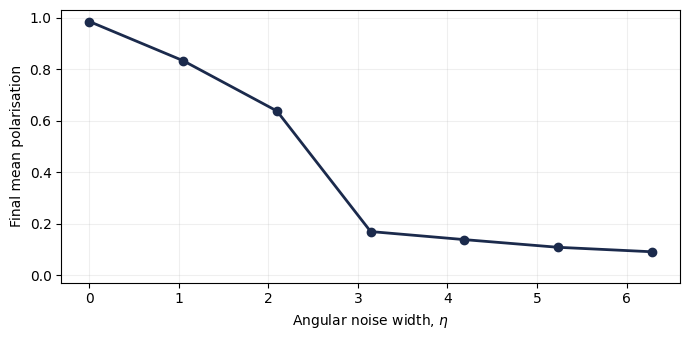

In [25]:
noise_values = np.linspace(0, 2 * np.pi, 7)
single_run_phi = []
for noise in tqdm(noise_values, desc="Single-run sweep"):
    params = VicsekParameters(noise=float(noise))
    _, headings = simulate_vicsek(params, steps=180, seed=SEED)
    single_run_phi.append(polarisation(headings[-40:]).mean())

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(noise_values, single_run_phi, "o-", color=INK, lw=2)
ax.set(xlabel="Angular noise width, $\\eta$", ylabel="Final mean polarisation", ylim=(-0.03, 1.03))
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()


# Then repeat each condition

An ensemble repeats the model at fixed parameter values with independent initial states and noise sequences. We summarise both the typical outcome and run-to-run variation.


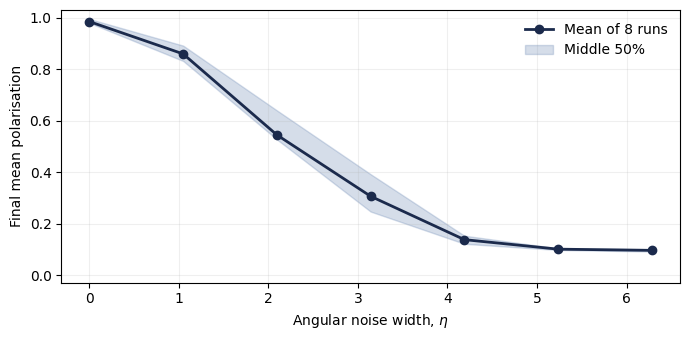

In [26]:
seeds = np.arange(8) + SEED
ensemble = np.empty((len(noise_values), len(seeds)))
for row, noise in enumerate(tqdm(noise_values, desc="Ensemble sweep")):
    params = VicsekParameters(noise=float(noise))
    for column, seed in enumerate(seeds):
        _, headings = simulate_vicsek(params, steps=180, seed=int(seed))
        ensemble[row, column] = polarisation(headings[-40:]).mean()

mean_phi = ensemble.mean(axis=1)
lower, upper = np.quantile(ensemble, [0.25, 0.75], axis=1)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(noise_values, mean_phi, "o-", color=INK, lw=2, label="Mean of 8 runs")
ax.fill_between(noise_values, lower, upper, color=BLUE, alpha=0.25, label="Middle 50%")
ax.set(xlabel="Angular noise width, $\\eta$", ylabel="Final mean polarisation", ylim=(-0.03, 1.03))
ax.grid(alpha=0.2)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## How many runs are enough?

There is no universal sufficient ensemble size. It depends on the variability of the outcome and the precision required for the claim. Begin with a pilot ensemble, then check whether the estimated mean and spread are still changing as runs are added.

The code below chooses the noise value with the widest middle 50% in the coarse sweep. This is a sensible stress test: conditions near a transition often vary more between runs than clearly ordered or disordered conditions.

> **Modelling decision:** specify a tolerance before increasing the ensemble. For example, require the running mean to change by less than 0.02 when the final eight runs are added, while also checking that the estimated standard deviation has stabilised. More runs reduce sampling uncertainty; they do not repair a short runtime, small world, or biased implementation.


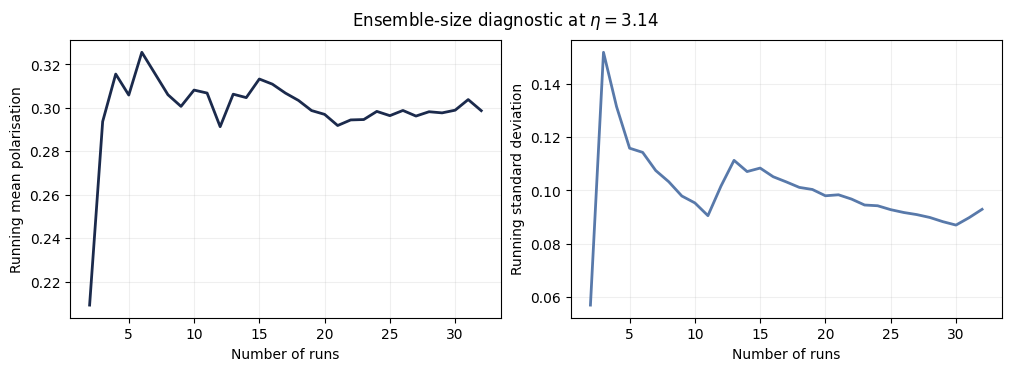

Change in mean after adding the final 8 runs: 0.000


In [27]:
pilot_size = 32
coarse_iqr = upper - lower
pilot_noise = float(noise_values[np.argmax(coarse_iqr)])
pilot_values = []

for seed in tqdm(np.arange(pilot_size) + SEED, desc="Ensemble-size pilot"):
    params = VicsekParameters(noise=pilot_noise)
    _, headings = simulate_vicsek(params, steps=180, seed=int(seed))
    pilot_values.append(polarisation(headings[-40:]).mean())

pilot_values = np.asarray(pilot_values)
ensemble_sizes = np.arange(2, pilot_size + 1)
running_mean = np.array([pilot_values[:n].mean() for n in ensemble_sizes])
running_sd = np.array([pilot_values[:n].std(ddof=1) for n in ensemble_sizes])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), constrained_layout=True)
axes[0].plot(ensemble_sizes, running_mean, color=INK, lw=2)
axes[0].set(ylabel="Running mean polarisation")
axes[1].plot(ensemble_sizes, running_sd, color=BLUE, lw=2)
axes[1].set(ylabel="Running standard deviation")
for ax in axes:
    ax.set(xlabel="Number of runs")
    ax.grid(alpha=0.2)
fig.suptitle(f"Ensemble-size diagnostic at $\\eta={pilot_noise:.2f}$")
plt.show()

mean_change = abs(running_mean[-1] - running_mean[-9])
print(f"Change in mean after adding the final 8 runs: {mean_change:.3f}")


> **Discuss:** Is the mean alone stable, or has the estimated spread also settled? Would the same number of runs be necessary far from the transition? State what evidence would persuade you that the ensemble is large enough for the precision of your conclusion.


## Refine the parameter grid where behaviour changes

A coarse sweep should locate broad behaviour first. It should not be mistaken for precise evidence about where or how a transition occurs. Once the steepest interval is identified, add parameter values inside that interval while retaining ensembles at every value.

This is adaptive allocation of a finite budget: use broad coverage to find the interesting region, then spend resolution there. A finer parameter grid without repeated runs can simply resolve stochastic noise more finely.


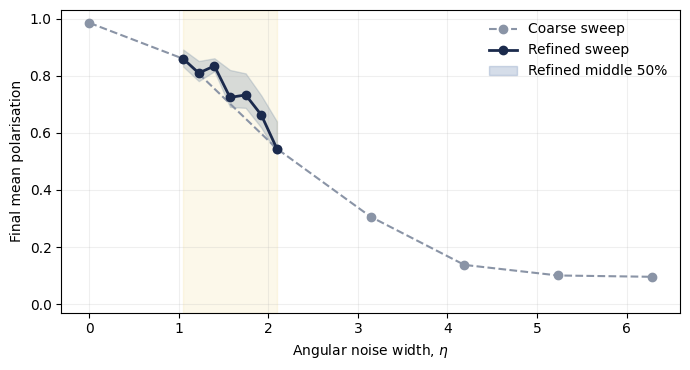

In [28]:
steepest_interval = int(np.argmax(np.abs(np.diff(mean_phi) / np.diff(noise_values))))
left, right = noise_values[steepest_interval:steepest_interval + 2]
refined_noise = np.linspace(left, right, 7)
refined = np.empty((len(refined_noise), len(seeds)))

for row, noise in enumerate(tqdm(refined_noise, desc="Refined ensemble sweep")):
    params = VicsekParameters(noise=float(noise))
    for column, seed in enumerate(seeds):
        _, headings = simulate_vicsek(params, steps=180, seed=int(seed))
        refined[row, column] = polarisation(headings[-40:]).mean()

refined_mean = refined.mean(axis=1)
refined_lower, refined_upper = np.quantile(refined, [0.25, 0.75], axis=1)

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(noise_values, mean_phi, "o--", color="#8A94A6", label="Coarse sweep")
ax.plot(refined_noise, refined_mean, "o-", color=INK, lw=2, label="Refined sweep")
ax.fill_between(refined_noise, refined_lower, refined_upper, color=BLUE, alpha=0.25,
                label="Refined middle 50%")
ax.axvspan(left, right, color=YELLOW, alpha=0.12)
ax.set(xlabel="Angular noise width, $\\eta$", ylabel="Final mean polarisation",
       ylim=(-0.03, 1.03))
ax.grid(alpha=0.2)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


> **Discuss:** Did refinement reveal a feature that the coarse grid concealed, or merely confirm the same broad change? If the goal were to determine the order of the transition, what additional changes to system size, runtime, initialisation and sampling would still be required?


## Compare two noise conventions

Noise can enter the update in different places.

- **Angular noise:** first calculate the local mean direction, then rotate it by a random angle of width $\eta$.
- **Vectorial noise:** add a random vector of relative magnitude $\xi$ to the local mean vector, then calculate the resulting angle.

These are different stochastic models. We sweep the normalised coordinates $\eta/(2\pi)$ and $\xi$ from zero to one, use the same seeds, and compare their finite-system order–disorder curves.

This first comparison is deliberately responsive: $N=80$ agents, 220 steps, nine noise values and eight runs per value. It can show that the noise convention changes the curve, but it is **not large or long enough to establish whether either transition is continuous or discontinuous**. In a finite system, averaging independent runs can also smooth over switching or coexistence.

> **Discuss:** Does changing where noise enters merely shift the apparent transition, or also alter its shape and run-to-run variation? What evidence would be required before calling either transition continuous or discontinuous?


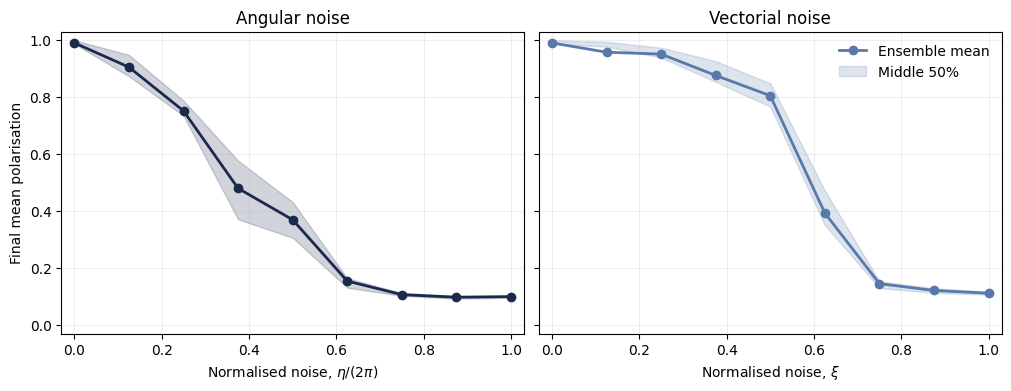

In [29]:
normalised_noise = np.linspace(0, 1, 9)
comparison_seeds = np.arange(8) + SEED
comparison_steps = 220
averaging_window = 50
noise_results = {}

for mode in ("angular", "vectorial"):
    values = np.empty((len(normalised_noise), len(comparison_seeds)))
    for row, level in enumerate(tqdm(normalised_noise, desc=f"{mode.capitalize()} noise")):
        noise_strength = 2 * np.pi * level if mode == "angular" else level
        params = VicsekParameters(noise=float(noise_strength), noise_mode=mode)
        for column, seed in enumerate(comparison_seeds):
            _, headings = simulate_vicsek(params, steps=comparison_steps, seed=int(seed))
            values[row, column] = polarisation(headings[-averaging_window:]).mean()
    noise_results[mode] = values

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True, constrained_layout=True)
for ax, mode, colour, symbol in zip(
    axes, ("angular", "vectorial"), (INK, BLUE), (r"$\eta/(2\pi)$", r"$\xi$")
):
    values = noise_results[mode]
    mean = values.mean(axis=1)
    lower, upper = np.quantile(values, [0.25, 0.75], axis=1)
    ax.plot(normalised_noise, mean, "o-", color=colour, lw=2, label="Ensemble mean")
    ax.fill_between(normalised_noise, lower, upper, color=colour, alpha=0.2, label="Middle 50%")
    ax.set(
        title=f"{mode.capitalize()} noise", xlabel=f"Normalised noise, {symbol}",
        xlim=(-0.03, 1.03), ylim=(-0.03, 1.03)
    )
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Final mean polarisation")
axes[1].legend(frameon=False)
plt.show()


The side-by-side panels keep each uncertainty band clear. An overlay can make horizontal shifts and differences in curve shape easier to see, provided the line styles and labels remain distinguishable without colour.

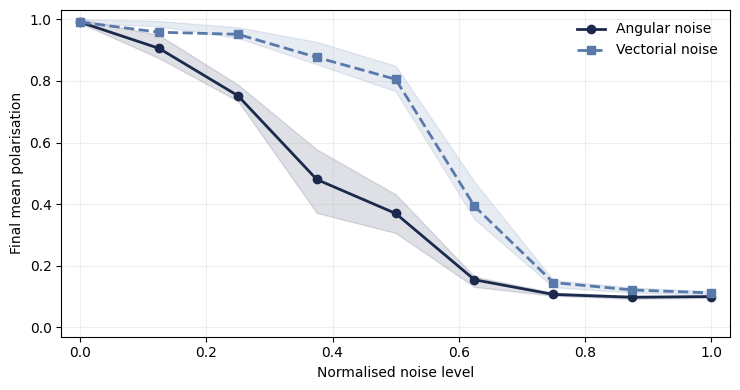

In [30]:
fig, ax = plt.subplots(figsize=(7.5, 4))
styles = {"angular": (INK, "o", "-"), "vectorial": (BLUE, "s", "--")}

for mode in ("angular", "vectorial"):
    colour, marker, linestyle = styles[mode]
    values = noise_results[mode]
    mean = values.mean(axis=1)
    lower, upper = np.quantile(values, [0.25, 0.75], axis=1)
    ax.plot(normalised_noise, mean, marker=marker, linestyle=linestyle,
            color=colour, lw=2, label=f"{mode.capitalize()} noise")
    ax.fill_between(normalised_noise, lower, upper, color=colour, alpha=0.14)

ax.set(xlabel="Normalised noise level", ylabel="Final mean polarisation",
       xlim=(-0.03, 1.03), ylim=(-0.03, 1.03))
ax.grid(alpha=0.2)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


> **Discuss:** Does the overlay support the same comparison as the separate panels? Normalising both controls to $[0,1]$ aligns their plotting range; it does not make angular and vectorial noise physically identical.


## Optional extension · look for a finite-system discontinuity

Vectorial noise is associated with a more abrupt, first-order transition in sufficiently large Vicsek systems. That does not mean a small finite simulation must display a vertical jump. The discontinuity is tied to phase coexistence and travelling density bands, and it becomes clearer as the domain and observation time increase.

A stronger diagnostic therefore changes the experiment as well as the noise rule:

1. keep density fixed while increasing the number of agents and box size;
2. use a finer noise grid near the transition and run longer;
3. sweep upward from an ordered state and downward from a disordered state, carrying the final state forward;
4. inspect spatial snapshots and the distribution of polarisation, not only its mean.

Different upward and downward branches provide finite-system evidence of hysteresis. Bimodal polarisation or ordered bands coexisting with disorder provide evidence of phase coexistence. A convincing claim about transition order would still require several system sizes and finite-size analysis.

> **Computational choice:** This extension is off by default because the transparent all-pairs neighbour calculation scales approximately as $N^2$ per step. Set `RUN_LARGE_SYSTEM_EXTENSION = True` when you have time to run it, and reduce `large_n`, `steps_per_level`, or the number of noise levels when testing the code.


In [ ]:
RUN_LARGE_SYSTEM_EXTENSION = False

large_n = 320
large_density = 2.0
large_box = np.sqrt(large_n / large_density)
vectorial_levels = np.linspace(0.35, 0.85, 17)
steps_per_level = 600
sample_window = 150

def vectorial_continuation(levels, ordered_start, seed):
    rng = np.random.default_rng(seed)
    params0 = VicsekParameters(
        n_agents=large_n, box_size=large_box, speed=0.5, radius=1.0,
        noise=float(levels[0]), noise_mode="vectorial"
    )
    positions, headings = initialise_vicsek(params0, rng)
    if ordered_start:
        headings[:] = 0.0
    branch_phi, branch_states = [], []
    for level in tqdm(levels, desc="Continuation"):
        params = VicsekParameters(
            n_agents=large_n, box_size=large_box, speed=0.5, radius=1.0,
            noise=float(level), noise_mode="vectorial"
        )
        recent_phi = []
        for step in range(steps_per_level):
            positions, headings = vicsek_step(positions, headings, params, rng)
            if step >= steps_per_level - sample_window:
                recent_phi.append(polarisation(headings))
        branch_phi.append(np.mean(recent_phi))
        branch_states.append((positions.copy(), headings.copy()))
    return np.asarray(branch_phi), branch_states

if RUN_LARGE_SYSTEM_EXTENSION:
    upward_phi, upward_states = vectorial_continuation(
        vectorial_levels, ordered_start=True, seed=SEED
    )
    downward_reversed_phi, downward_reversed_states = vectorial_continuation(
        vectorial_levels[::-1], ordered_start=False, seed=SEED + 1
    )
    downward_phi = downward_reversed_phi[::-1]
    downward_states = downward_reversed_states[::-1]

    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    ax.plot(vectorial_levels, upward_phi, "o-", color=INK, label="Increasing noise · ordered start")
    ax.plot(vectorial_levels, downward_phi, "s--", color=BLUE, label="Decreasing noise · disordered start")
    ax.set(xlabel=r"Vectorial noise, $\xi$", ylabel=r"Mean polarisation, $\Phi$", ylim=(-0.03, 1.03))
    ax.grid(alpha=0.2)
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()
else:
    print("Optional larger-system continuation not run. Set RUN_LARGE_SYSTEM_EXTENSION = True to enable it.")


If the two branches separate, inspect the corresponding configurations rather than treating the gap alone as proof. Travelling high-density bands and switching between ordered and disordered states are part of the mechanism that a small box may suppress. If the branches do not separate, increase the system size and runtime before concluding that the transition is continuous.

> **Discuss:** Which changed ingredient—system size, duration, initialisation, noise resolution, or observable—most alters the conclusion? What additional evidence would you require before extrapolating from these finite simulations to a large-system phase transition?


# Interpret the evidence

Discuss:

1. Which feature of the single-run sweep persists across the ensemble?
2. Where is run-to-run variation largest?
3. Does this finite simulation establish a universal critical noise or the order of a phase transition? Why not?
4. What alternative observable would detect rotation or multiple counter-moving groups?


# Choose an extension

## A · Change the interaction network

Replace the metric radius with the $k$ nearest neighbours.

## B · Change the update convention

The supplied model moves using the old heading. Change it so agents move using the newly aligned heading, then compare the result.

## C · Challenge the observable

Construct an organised state with low polarisation and propose a second measure.

## D · Test robustness

Repeat the ensemble with a larger population, longer settling period, or different density.


In [17]:
# Choose one extension and record its baseline and modified outcomes.
# Keep every unrelated modelling choice fixed so the comparison is interpretable.

extension_results = {
    "question": "",
    "baseline_choice": "",
    "modified_choice": "",
    "observable": "",
    "baseline_result": np.nan,
    "modified_result": np.nan,
}

# Add your simulation and plotting code below.
extension_results


{'question': '',
 'baseline_choice': '',
 'modified_choice': '',
 'observable': '',
 'baseline_result': nan,
 'modified_result': nan}

# Modelling practice checkpoint

State where noise entered each implementation and identify one conclusion that changed or became less certain when the noise convention changed.


# Exit ticket

Record:

1. one local modelling choice that materially affected the collective result;
2. one test that increased your confidence in the implementation;
3. one conclusion supported by the ensemble;
4. one conclusion the experiment does not support.
